In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# example data from
# Vercellino et al., “Measurement of Generative AI Workload Power Profiles for Whole-Facility Data Center Infrastructure Planning,”
# [arXiv:2604.07345](https://arxiv.org/abs/2604.07345) (2026)
df = pd.read_parquet("000024.parquet")

<Axes: xlabel='timestep[s]'>

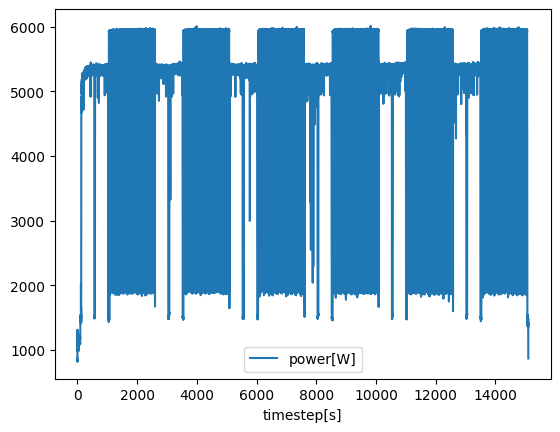

In [2]:
df[:].plot()

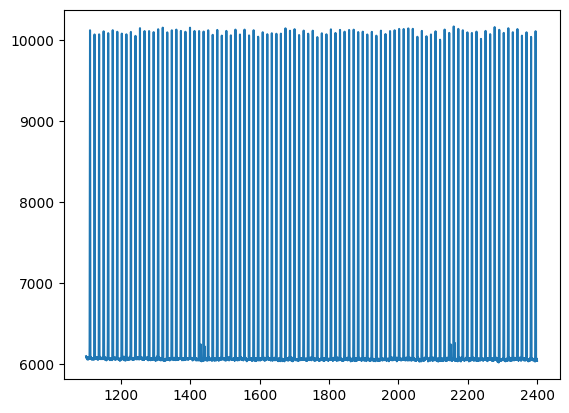

In [3]:

profile = -df[5500:12000]["power[W]"]+12e3
plt.plot(profile)

In [16]:
from simses.battery.battery import Battery
from simses.converter.converter import Converter
from simses.ems.ems import EMS
from simses.model.cell.skeleton_sca3200 import SCA3200
from simses.model.cell.sony_lfp import SonyLFP
from simses.model.converter.sinamics import SinamicsS120Fit

cell_1 = SonyLFP()

battery_1 = Battery(
    cell=cell_1,
    circuit=(15, 11),
    initial_states={"start_soc": 1.0, "start_T": 25.0},
    degradation=True,
)

converter_1 = Converter(
    loss_model=SinamicsS120Fit(),
    max_power=6.5e3,
    storage=battery_1,
)

cell_2 = SCA3200()

battery_2 = Battery(
    cell_2,
    circuit=(1,1),
    initial_states={"start_soc": 1.0, "start_T": 25.0}
)

ems = EMS(converter_1, battery_2, 1.0)

In [17]:
from datetime import timedelta

import numpy as np
from tqdm import tqdm

dt = 0.2
duration = timedelta(minutes=15)

n_steps = int(duration.total_seconds()/dt)

grid_power = 0

log_batt = {k: np.empty(n_steps) for k in ["soc", "v", "i", "power", "power_setpoint", "loss"]}
log_scap = {k: np.empty(n_steps) for k in ["soc", "v", "i", "power", "power_setpoint", "loss"]}
log_general = {k: np.empty(n_steps) for k in ["ems_fulfillment"]}


for i in tqdm(range(n_steps)):
    profile_power = profile.iloc[i]
    step_power = grid_power - profile_power
    ems.step(step_power, dt)

    for k in log_batt:
        log_batt[k][i] = getattr(battery_1.state, k)
    for k in log_scap:
        log_scap[k][i] = getattr(battery_2.state, k)

    log_general["ems_fulfillment"][i] = 1 -  (step_power -battery_2.state.power-converter_1.state.power)/step_power

index = pd.date_range("2025-01-01", periods=n_steps, freq=f"{int(dt*1000)}ms")
df_batt = pd.DataFrame(log_batt, index=index)
df_scap = pd.DataFrame(log_scap, index=index)
df_general = pd.DataFrame(log_general, index=index)


100%|██████████| 4500/4500 [00:00<00:00, 43736.43it/s]


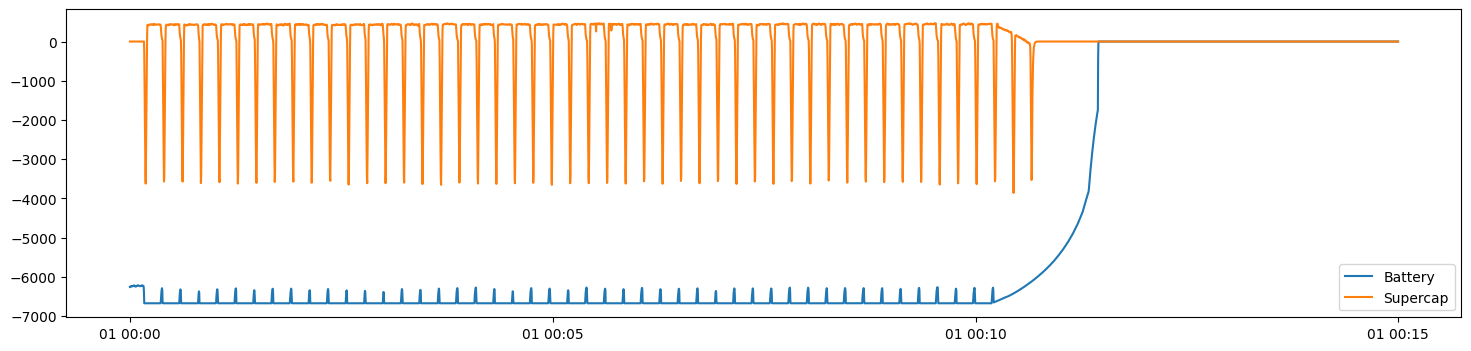

In [18]:
fig, ax = plt.subplots(1,1, figsize=(18,4))
ax.plot(df_batt["power"], label="Battery")
ax.plot(df_scap["power"], label="Supercap")
ax.legend(loc="lower right")


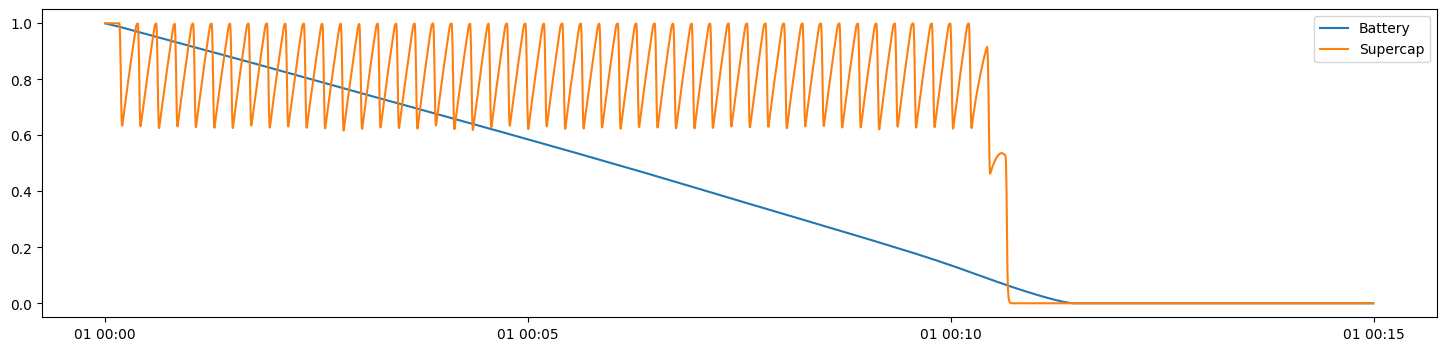

In [19]:
fig, ax = plt.subplots(1,1, figsize=(18,4))
ax.plot(df_batt["soc"], label="Battery")
ax.plot(df_scap["soc"], label="Supercap")
ax.legend(loc="upper right")

<Axes: >

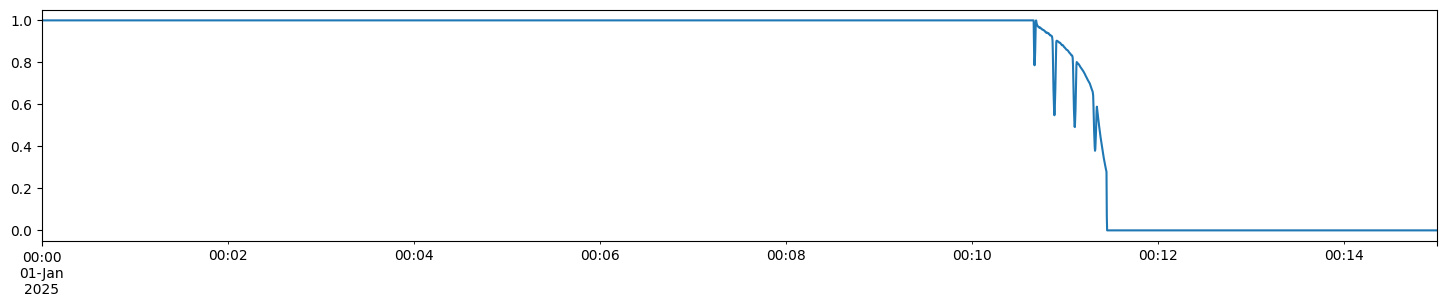

In [20]:
df_general["ems_fulfillment"].plot(figsize=(18,3))

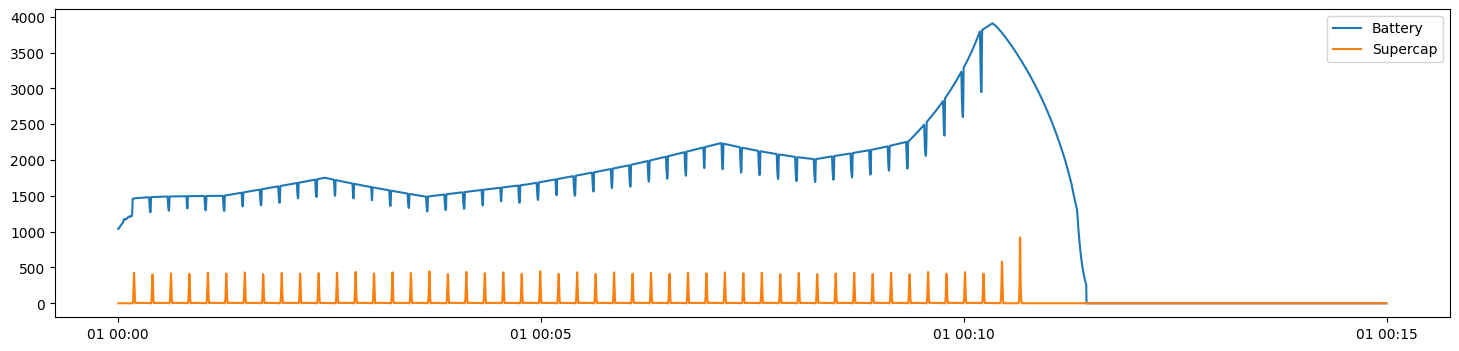

In [21]:
fig, ax = plt.subplots(1,1, figsize=(18,4))
ax.plot(df_batt["loss"], label="Battery")
ax.plot(df_scap["loss"], label="Supercap")
ax.legend(loc="upper right")